# Modeling U.S. Credit Response to Rising Interest Rates 

## Step 1: Imports & Environment Setup

### Imports

In [1]:
import os
import sys
from pathlib import Path
from typing import Dict, Any

import yaml
import logging

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from fredapi import Fred
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

### Verfiy Assets

In [2]:
logger = logging.getLogger("consumer-credit-analysis")

SECRETS_PATH = "../secrets.yaml"

if Path(SECRETS_PATH).exists():
        logger.info("secrets.yaml is properly configured.")
else:
    logger.info('secrets.yaml is not properly configured. Create a secrets.yaml file and add in your FRED API Key. i.e. `FRED_API_KEY:"XXXXXXXXXXXXXXXXXXXXXXX"`')


### Load Secrets File

In [3]:
def _load_yaml_file(path: str, name: str) -> Dict[str, Any]:
    """
    Helper to load any YAML file with a consistent error message.
    """
    abs_path = os.path.abspath(path)
    if not os.path.exists(abs_path):
        raise FileNotFoundError(f"{name} file not found at: {abs_path}")
    with open(abs_path, "r") as f:
        return yaml.safe_load(f) or {}

def load_secrets(secrets_path: str = "secrets.yaml") -> Dict[str, Any]:
    """
    Load application secrets from a YAML file.
    Args:
        secrets_path: Path to the secrets YAML file.

    Returns:
        Secrets dict.

    Raises:
        FileNotFoundError: If the secrets file is not found.
    """
    # If using an external secrets manager, you can create
    # an (empty) secrets.yaml stub in this path to satisfy the loader.
    return _load_yaml_file(secrets_path, "secrets.yaml")

secrets = load_secrets(SECRETS_PATH)
logger.info("Secrets Loaded")

### Setup FRED API Key

In [4]:
api_key = secrets.get("FRED_API_KEY")
fred = Fred(api_key=api_key)
logger.info("FRED API Key Successfully Setup.")

## Step 2: Data Download + Cleaning

In [5]:
# Download data
credit = fred.get_series('TOTALSL')
revolving = fred.get_series('REVOLSL')
nonrev = fred.get_series('NONREVSL')
fedfunds = fred.get_series('FEDFUNDS')
lending = fred.get_series('DRCCLACBS')


# Combine
df = pd.DataFrame({
    'credit_total': credit,
    'revolving': revolving,
    'nonrevolving': nonrev,
    'fedfunds': fedfunds,
    'lending_std': lending
})

df = df.dropna()
logger.info("Datasets loaded and cleaned.")

## Step 3: Exploratory Data Analysis (EDA)

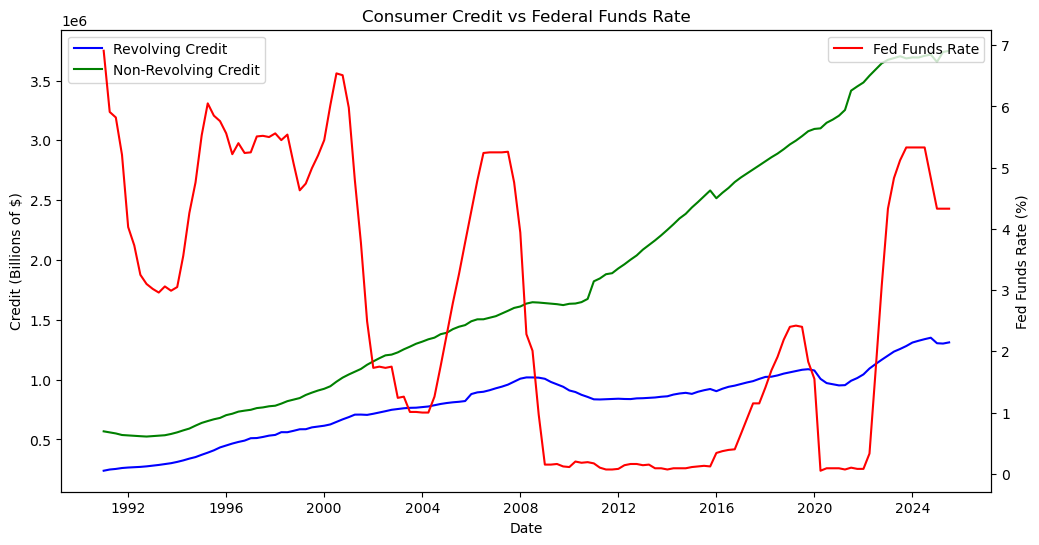

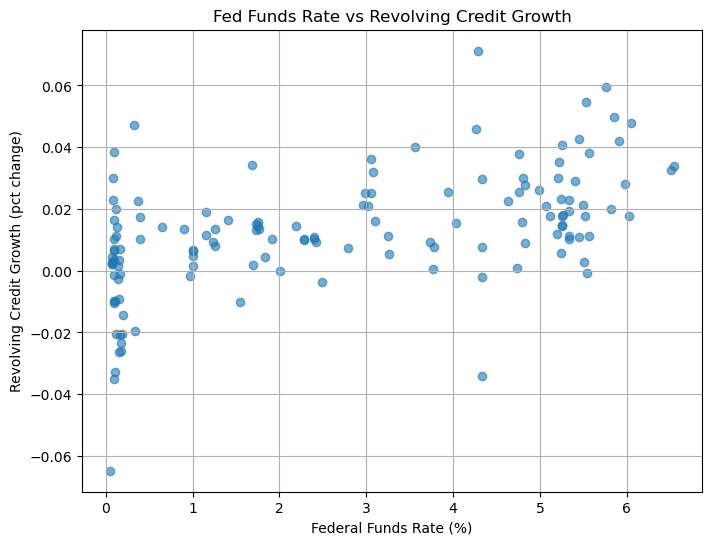

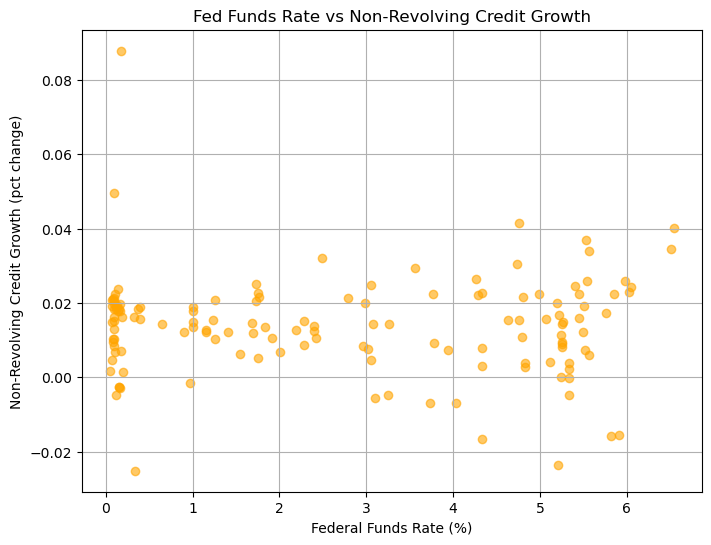

In [6]:
# --- Growth rate calculations ---
df['revolving_growth'] = df['revolving'].pct_change()
df['nonrev_growth'] = df['nonrevolving'].pct_change()

# ---------------------------------------------------------------
# TIME-SERIES PLOT with dual y-axes (so fed funds is visible)
# ---------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12,6))

# Plot credit levels
ax1.plot(df.index, df['revolving'], label='Revolving Credit', color='blue')
ax1.plot(df.index, df['nonrevolving'], label='Non-Revolving Credit', color='green')
ax1.set_xlabel("Date")
ax1.set_ylabel("Credit (Billions of $)")
ax1.legend(loc="upper left")

# Second axis for Fed Funds Rate
ax2 = ax1.twinx()
ax2.plot(df.index, df['fedfunds'], label='Fed Funds Rate', color='red')
ax2.set_ylabel("Fed Funds Rate (%)")
ax2.legend(loc="upper right")

plt.title("Consumer Credit vs Federal Funds Rate")
plt.show()

# ---------------------------------------------------------------
# SCATTER PLOTS (Cleaned for NaNs)
# ---------------------------------------------------------------
df_scatter = df[['fedfunds', 'revolving_growth', 'nonrev_growth']].dropna()

# Revolving credit growth vs interest rate
plt.figure(figsize=(8,6))
plt.scatter(df_scatter['fedfunds'], df_scatter['revolving_growth'], alpha=0.6)
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("Revolving Credit Growth (pct change)")
plt.title("Fed Funds Rate vs Revolving Credit Growth")
plt.grid(True)
plt.show()

# Non-revolving credit growth vs interest rate
plt.figure(figsize=(8,6))
plt.scatter(df_scatter['fedfunds'], df_scatter['nonrev_growth'], alpha=0.6, color='orange')
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("Non-Revolving Credit Growth (pct change)")
plt.title("Fed Funds Rate vs Non-Revolving Credit Growth")
plt.grid(True)
plt.show()


## Step 4: Modeling

### Setup & Helper Functions

In [7]:

df["revolving_growth_12m"] = df["revolving"].pct_change(12)
df["nonrev_growth_12m"] = df["nonrevolving"].pct_change(12)

# Lagged Fed Funds rate: 0, 3, 6, 12 months
for lag in [0, 3, 6, 12]:
    df[f"fedfunds_lag{lag}"] = df["fedfunds"].shift(lag)

df_model = df[
    [
        "revolving_growth_12m",
        "nonrev_growth_12m",
        "fedfunds_lag0",
        "fedfunds_lag3",
        "fedfunds_lag6",
        "fedfunds_lag12",
    ]
].dropna()

print("Model dataframe shape:", df_model.shape)
display(df_model.head())


Model dataframe shape: (127, 6)


,revolving_growth_12m,nonrev_growth_12m,fedfunds_lag0,fedfunds_lag3,fedfunds_lag6,fedfunds_lag12
1994-01-01,0.309184,-0.014766,3.05,2.96,3.25,6.91
1994-04-01,0.306628,0.030226,3.56,3.06,3.10,5.91
1994-07-01,0.339844,0.074289,4.26,2.99,3.02,5.82
1994-10-01,0.349843,0.145962,4.76,3.05,2.96,5.21
1995-01-01,0.401741,0.196395,5.53,3.56,3.06,4.03


In [8]:
features_rate = ["fedfunds_lag0", "fedfunds_lag3", "fedfunds_lag6", "fedfunds_lag12"]

print("Columns in df_model:", df_model.columns.tolist())
print("Feature set:", features_rate)

def run_time_series_model(
    X: pd.DataFrame,
    y: pd.Series,
    estimator,
    model_name: str,
    target_label: str,
    test_size: float = 0.2,
    plot: bool = False,
):
    """
    Train/test split without shuffling (respect time order),
    fit the model, compute R^2 and RMSE, optionally plot.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )

    model = estimator.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n=== {model_name} ===")
    print(f"Target: {target_label}")
    print(f"Features: {list(X.columns)}")
    print(f"R^2 (test): {r2:.3f}")
    print(f"RMSE (test): {rmse:.4f}")

    # Coefficients for linear regression
    if hasattr(model, "coef_"):
        print("Coefficients:")
        for name, coef in zip(X.columns, model.coef_):
            print(f"  {name}: {coef:.4f}")
        print(f"Intercept: {model.intercept_:.4f}")

    # Feature importances for Random Forest
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=X.columns)
        print("\nFeature importances:")
        display(importances.sort_values(ascending=False))

    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(y_test.index, y_test, label="Actual", linewidth=1.5)
        plt.plot(
            y_test.index,
            y_pred,
            label="Predicted",
            linestyle="--",
            linewidth=1.5,
        )
        plt.xlabel("Date")
        plt.ylabel(target_label)
        plt.title(model_name + " - Actual vs Predicted")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return {
        "model_name": model_name,
        "target": target_label,
        "features": "fedfunds_lags",
        "r2": r2,
        "rmse": rmse,
    }, y_test, y_pred, model


results = []


Columns in df_model: ['revolving_growth_12m', 'nonrev_growth_12m', 'fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12']
Feature set: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12']


### Model 1a: Linear Regression for revolving credit growth (12month)
Question: Do higher interest rates reduce revolving credit growth?


=== LR - Revolving 12m Growth (Fed Funds) ===
Target: Revolving 12m Growth (pct)
Features: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12']
R^2 (test): 0.648
RMSE (test): 0.0869
Coefficients:
  fedfunds_lag0: 0.0477
  fedfunds_lag3: -0.0030
  fedfunds_lag6: 0.0379
  fedfunds_lag12: -0.0085
Intercept: -0.0079


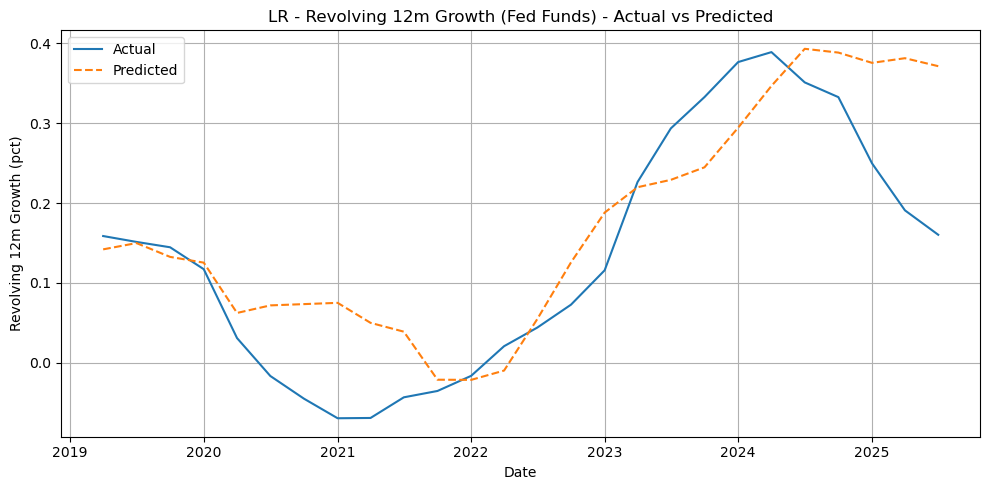

In [9]:
X_rev = df_model[features_rate]
y_rev = df_model["revolving_growth_12m"]

res1, y1_test, y1_pred, lr_rev = run_time_series_model(
    X_rev,
    y_rev,
    LinearRegression(),
    "LR - Revolving 12m Growth (Fed Funds)",
    "Revolving 12m Growth (pct)",
    plot=True,  # keep a nice plot for this one
)
results.append(res1)


### Model 1b: Random Forest for revolving credit growth (12month)


=== Random Forest – Revolving 12m Growth (Fed Funds) ===
Target: Revolving 12m Growth (pct)
Features: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12']
R^2 (test): 0.768
RMSE (test): 0.0705

Feature importances:


fedfunds_lag3     0.580522
fedfunds_lag0     0.167716
fedfunds_lag6     0.149505
fedfunds_lag12    0.102257
dtype: float64

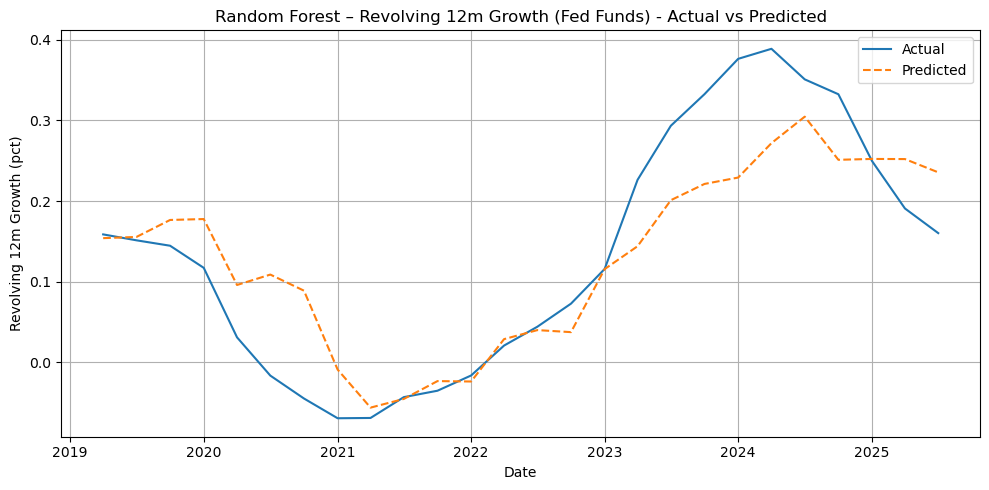

In [10]:
rf_rev = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=3,
)

res2, y2_test, y2_pred, rf_rev_fit = run_time_series_model(
    X_rev,
    y_rev,
    rf_rev,
    "Random Forest – Revolving 12m Growth (Fed Funds)",
    "Revolving 12m Growth (pct)",
    plot=True,
)
results.append(res2)


### Model 2a: Linear Regression for non-revolving credit growth
Question: Is non-revolving credit less sensitive to rate changes?


=== LR – Non-Revolving 12m Growth (Fed Funds Only) ===
Target: Non-Revolving 12m Growth (pct)
Features: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12']
R^2 (test): -6.038
RMSE (test): 0.1163
Coefficients:
  fedfunds_lag0: -0.0049
  fedfunds_lag3: 0.0119
  fedfunds_lag6: 0.0106
  fedfunds_lag12: -0.0104
Intercept: 0.2013


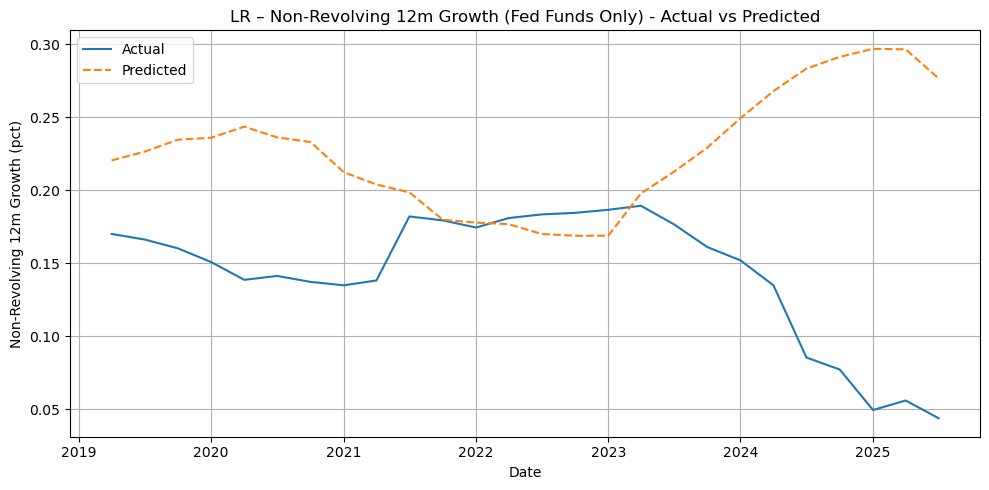

In [ ]:
y_nonrev = df_model["nonrev_growth_12m"]

res3, y3_test, y3_pred, lr_nonrev = run_time_series_model(
    X_rev,  # same features: Fed Funds lags
    y_nonrev,
    LinearRegression(),
    "LR - Non-Revolving 12m Growth (Fed Funds Only)",
    "Non-Revolving 12m Growth (pct)",
    plot=True,
)
results.append(res3)

### Model 2b: Random Forest for non-revolving credit growth


=== Random Forest – Non-Revolving 12m Growth (Fed Funds Only) ===
Target: Non-Revolving 12m Growth (pct)
Features: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12']
R^2 (test): -1.071
RMSE (test): 0.0631

Feature importances:


fedfunds_lag6     0.306490
fedfunds_lag3     0.255311
fedfunds_lag12    0.240832
fedfunds_lag0     0.197367
dtype: float64

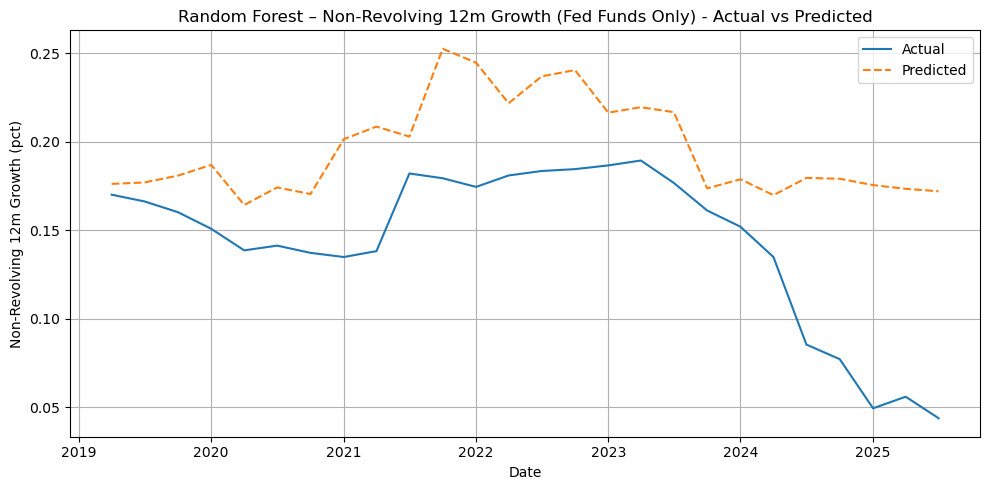

In [12]:
rf_nonrev = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=3,
)

res4, y4_test, y4_pred, rf_nonrev_fit = run_time_series_model(
    X_rev,
    y_nonrev,
    rf_nonrev,
    "Random Forest – Non-Revolving 12m Growth (Fed Funds Only)",
    "Non-Revolving 12m Growth (pct)",
    plot=True,
)
results.append(res4)

In [13]:
results_df = pd.DataFrame(results)
display(results_df)

,model_name,target,features,r2,rmse
0,LR - Revolving 12m Growth (Fed Funds),Revolving 12m Growth (pct),fedfunds_lags,0.647925,0.086886
1,Random Forest – Revolving 12m Growth (Fed Funds),Revolving 12m Growth (pct),fedfunds_lags,0.768354,0.070477
2,LR – Non-Revolving 12m Growth (Fed Funds Only),Non-Revolving 12m Growth (pct),fedfunds_lags,-6.037617,0.116300
3,Random Forest – Non-Revolving 12m Growth (Fed ...,Non-Revolving 12m Growth (pct),fedfunds_lags,-1.070923,0.063088
